In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('Grammar Correction.csv')

In [ ]:
print("Original shape:", df.shape)
print(df.head(5))

Original shape: (2018, 4)
   Serial Number         Error Type              Ungrammatical Statement  \
0              1  Verb Tense Errors        I goes to the store everyday.   
1              2  Verb Tense Errors  They was playing soccer last night.   
2              3  Verb Tense Errors     She have completed her homework.   
3              4  Verb Tense Errors            He don't know the answer.   
4              5  Verb Tense Errors            The sun rise in the east.   

                       Standard English  
0           I go to the store everyday.  
1  They were playing soccer last night.  
2       She has completed her homework.  
3           He doesn't know the answer.  
4            The sun rises in the east.  


In [ ]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 Serial Number              0
Error Type                 0
Ungrammatical Statement    0
Standard English           0
dtype: int64


In [ ]:
df.drop(columns=['Serial Number'])

,Error Type,Ungrammatical Statement,Standard English
0,Verb Tense Errors,I goes to the store everyday.,I go to the store everyday.
1,Verb Tense Errors,They was playing soccer last night.,They were playing soccer last night.
2,Verb Tense Errors,She have completed her homework.,She has completed her homework.
3,Verb Tense Errors,He don't know the answer.,He doesn't know the answer.
4,Verb Tense Errors,The sun rise in the east.,The sun rises in the east.
...,...,...,...
2013,Lack of Parallelism in Lists or Series,"The festival celebrates music, culture, and to...","The festival celebrates music, culture, and br..."
2014,Lack of Parallelism in Lists or Series,The seminar will address topics such as career...,The seminar will address topics such as career...
2015,Lack of Parallelism in Lists or Series,The research examines the effects of climate c...,The research examines the effects of climate c...
2016,Lack of Parallelism in Lists or Series,"The report highlights the need for investment,...","The report highlights the need for investment,..."


In [ ]:
# Strip whitespace
df['Ungrammatical Statement'] = df['Ungrammatical Statement'].str.strip()
df['Standard English'] = df['Standard English'].str.strip()

In [ ]:
#removig null rows after stripping
df = df[
    (df['Ungrammatical Statement'].str.len() > 0) &
    (df['Standard English'].str.len() > 0)
]

In [ ]:
#removing duplicates
df = df.drop_duplicates(subset=['Ungrammatical Statement', 'Standard English'])

In [ ]:
if 'Error Type' in df.columns:
    print("\nError Type distribution:")
    print(df['Error Type'].value_counts(dropna=False))
    print("\nError Type (normalized):")
    print(df['Error Type'].value_counts(normalize=True).round(3))


Error Type distribution:
Error Type
Sentence Structure Errors                         103
Verb Tense Errors                                 100
Article Usage                                     100
Subject-Verb Agreement                            100
Spelling Mistakes                                 100
Preposition Usage                                  95
Punctuation Errors                                 60
Relative Clause Errors                             51
Negation Errors                                    50
Slang, Jargon, and Colloquialisms                  50
Tautology                                          50
Mixed Metaphors/Idioms                             50
Gerund and Participle Errors                       50
Lack of Parallelism in Lists or Series             50
Abbreviation Errors                                50
Ambiguity                                          49
Agreement in Comparative and Superlative Forms     49
Conjunction Misuse                           

Text(0, 0.5, 'Count')

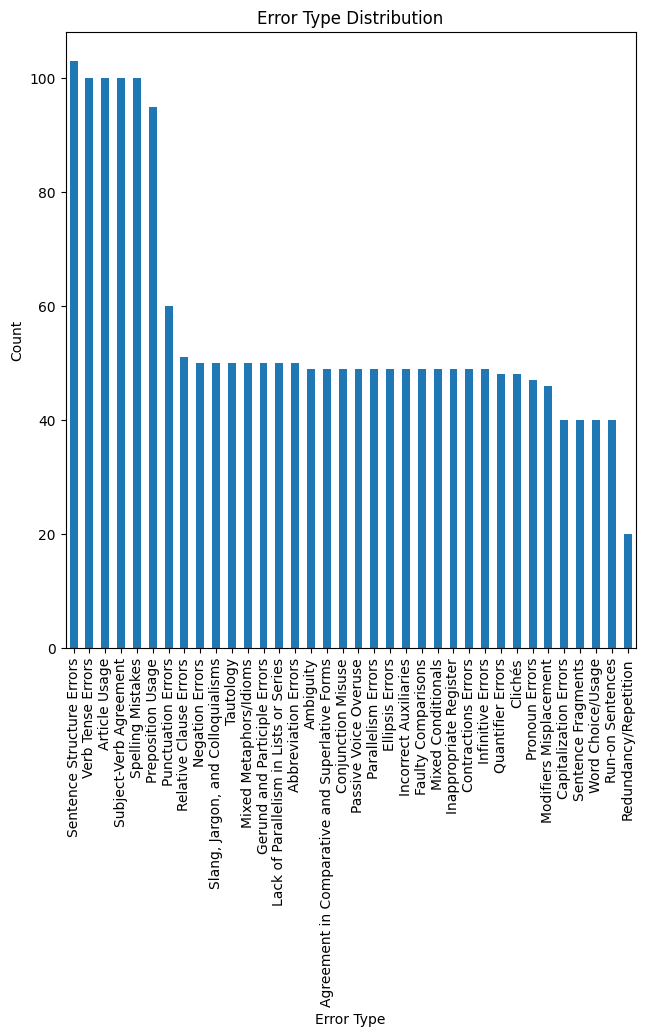

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 8))

plt.subplot(1, 3, 1)
df['Error Type'].value_counts().plot(kind='bar')
plt.title('Error Type Distribution')
plt.ylabel('Count')

In [ ]:
#Combining error types to reduce error type categories
mapping = {
    "Sentence Structure Errors": "Sentence Structure",
    "Run-on Sentences": "Sentence Structure",
    "Sentence Fragments": "Sentence Structure",
    "Modifiers Misplacement": "Sentence Structure",
    "Relative Clause Errors": "Sentence Structure",
    "Ellipsis Errors": "Sentence Structure",

    "Verb Tense Errors": "Verb & Tense",
    "Incorrect Auxiliaries": "Verb & Tense",
    "Gerund and Participle Errors": "Verb & Tense",
    "Infinitive Errors": "Verb & Tense",
    "Mixed Conditionals": "Verb & Tense",

    "Subject-Verb Agreement": "Agreement",
    "Agreement in Comparative and Superlative Forms": "Agreement",

    "Article Usage": "Articles & Quantifiers",
    "Quantifier Errors": "Articles & Quantifiers",

    "Preposition Usage": "Prepositions & Conjunctions",
    "Conjunction Misuse": "Prepositions & Conjunctions",

    "Pronoun Errors": "Pronouns & Negation",
    "Negation Errors": "Pronouns & Negation",

    "Punctuation Errors": "Punctuation & Capitalization",
    "Capitalization Errors": "Punctuation & Capitalization",
    "Abbreviation Errors": "Punctuation & Capitalization",
    "Contractions Errors": "Punctuation & Capitalization",

    "Word Choice/Usage": "Word Choice & Register",
    "Slang, Jargon, and Colloquialisms": "Word Choice & Register",
    "Inappropriate Register": "Word Choice & Register",

    "Redundancy/Repetition": "Redundancy & Style",
    "Tautology": "Redundancy & Style",
    "Clichés": "Redundancy & Style",
    "Passive Voice Overuse": "Redundancy & Style",

    "Ambiguity": "Logical/Semantic",
    "Faulty Comparisons": "Logical/Semantic",
    "Mixed Metaphors/Idioms": "Logical/Semantic",

    "Parallelism Errors": "Parallelism",
    "Lack of Parallelism in Lists or Series": "Parallelism"
}

df["Error Type"] = df["Error Type"].replace(mapping)

In [ ]:
df["Error Type"].value_counts()

,count
Error Type,
Sentence Structure,329
Verb & Tense,297
Punctuation & Capitalization,199
Redundancy & Style,167
Agreement,149
Articles & Quantifiers,148
Logical/Semantic,148
Prepositions & Conjunctions,144
Word Choice & Register,139


Text(0, 0.5, 'Count')

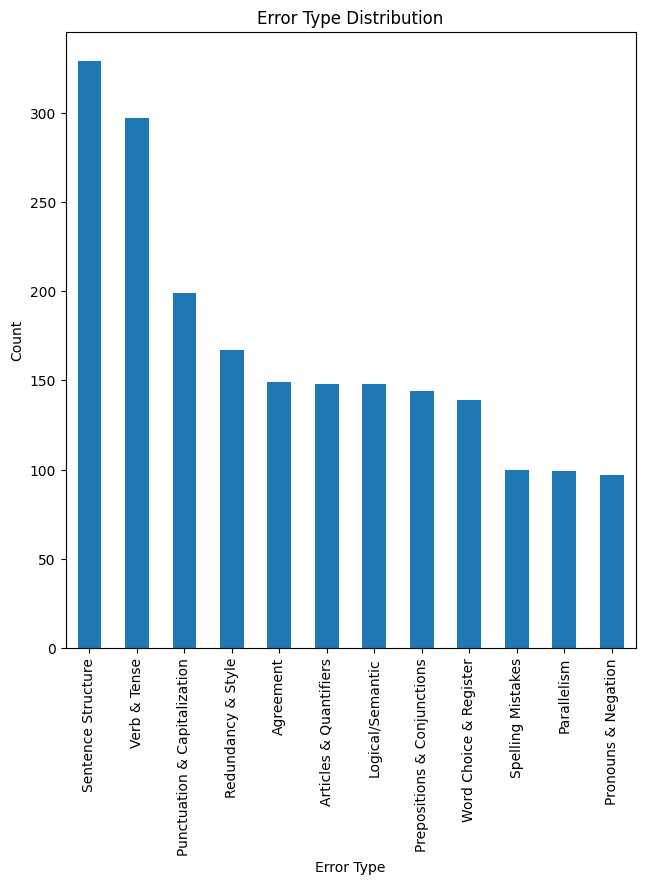

In [ ]:
#After grouping

plt.figure(figsize=(25, 8))

plt.subplot(1, 3, 1)
df['Error Type'].value_counts().plot(kind='bar')
plt.title('Error Type Distribution')
plt.ylabel('Count')

In [ ]:
#Oversamping minor classes
min_samples = 100
balanced = []

for label in df["Error Type"].unique():
    subset = df[df["Error Type"] == label]

    if len(subset) < min_samples:
        subset = subset.sample(min_samples, replace=True)

    balanced.append(subset)

df = pd.concat(balanced)

In [ ]:
df["target_text"] = (
    "Correction: " + df["Standard English"] +
    " Error Type: " + df["Error Type"]

)

df["input_text"] = "correct and identify error: " + df["Ungrammatical Statement"]

In [ ]:
#shuffling the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.1,
    stratify=df["Error Type"],
    random_state=42
)

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

print(train_dataset)

Dataset({
    features: ['Serial Number', 'Error Type', 'Ungrammatical Statement', 'Standard English', 'target_text', 'input_text', '__index_level_0__'],
    num_rows: 1814
})


In [ ]:
from transformers import T5Tokenizer

t5_tokenizer = T5Tokenizer.from_pretrained("t5-small")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
max_input_length = 128
max_target_length = 128

def tokenize_function(example):

    model_inputs = t5_tokenizer(
        example["input_text"],
        max_length=max_input_length,
        padding="max_length",
        truncation=True
    )

    labels = t5_tokenizer(
        example["target_text"],
        max_length=max_target_length,
        padding="max_length",
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

In [ ]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

In [ ]:
tokenized_train = train_dataset.map(tokenize_function)
tokenized_test = test_dataset.map(tokenize_function)

In [ ]:
tokenized_train = tokenized_train.remove_columns(train_dataset.column_names)
tokenized_test = tokenized_test.remove_columns(test_dataset.column_names)

In [ ]:
tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

In [ ]:
from transformers import T5ForConditionalGeneration

t5_model = T5ForConditionalGeneration.from_pretrained("t5-small")

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

t5_model.to(device)

print("Using device:", device)

Using device: cuda


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    num_train_epochs=8,
    logging_dir="./logs",
    fp16=torch.cuda.is_available()
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=t5_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test
)

In [ ]:
trainer.train()

Step,Training Loss
500,0.891583
1000,0.100736
1500,0.076670


TrainOutput(global_step=1816, training_loss=0.3070251490051001, metrics={'train_runtime': 293.6494, 'train_samples_per_second': 49.419, 'train_steps_per_second': 6.184, 'total_flos': 491020055740416.0, 'train_loss': 0.3070251490051001, 'epoch': 8.0})

In [ ]:
def predict_grammar(sentence):

    t5_model.eval()

    text = "correct and identify error: " + sentence

    inputs = t5_tokenizer(text, return_tensors="pt").to(device)

    outputs = t5_model.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=120,
        num_beams=5,
        early_stopping=True
    )

    prediction = t5_tokenizer.decode(outputs[0], skip_special_tokens=True)



    return prediction

In [ ]:
while True:

    sentence = input("\nEnter sentence (or type 'exit' to stop): ")

    if sentence.lower() == "exit":
        print("Program stopped.")
        break

    result = predict_grammar(sentence)

    # Split output parts
    correction = ""
    error_type = ""
    marked_sentence = ""

    if "Correction:" in result:
        correction = result.split("Correction:")[1].split("Error Type:")[0].strip()

    if "Error Type:" in result:
        error_type = result.split("Error Type:")[1].split("Marked Sentence:")[0].strip()



    print("\nPrediction:")
    print("Correction      :", correction)
    print("Error Type      :", error_type)
    # print("Marked Sentence :", marked_sentence)


Enter sentence (or type 'exit' to stop): She go to school.

Prediction:
Correction      : She goes to school.
Error Type      : Verb & Tense

Enter sentence (or type 'exit' to stop): i havent gone yet.

Prediction:
Correction      : I haven't gone yet.
Error Type      : Verb & Tense

Enter sentence (or type 'exit' to stop): he living in delhi

Prediction:
Correction      : He lives in delhi, and he lives in delhi.
Error Type      : Verb & Tense

Enter sentence (or type 'exit' to stop): exit
Program stopped.


## Evaluation

In [ ]:
pip install nltk scikit-learn

In [ ]:
import re
from nltk.translate.gleu_score import sentence_gleu
from sklearn.metrics import f1_score

In [ ]:
def parse_prediction(result):

    correction = ""
    error_type = ""
    marked_sentence = ""

    if "Correction:" in result:
        correction = result.split("Correction:")[1].split("Error Type:")[0].strip()

    if "Error Type:" in result:
        error_type = result.split("Error Type:")[1].split("Marked Sentence:")[0].strip()



    return correction, error_type, marked_sentence

In [ ]:
!pip install errant spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 113.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import errant
from nltk.translate.gleu_score import sentence_gleu
from collections import defaultdict

def evaluate_model(test_df, model, tokenizer):
    import errant
    from nltk.translate.gleu_score import sentence_gleu
    from collections import defaultdict

    annotator = errant.load("en")


    src = test_df["Ungrammatical Statement"].tolist()
    ref = test_df["Standard English"].tolist()


    def generate_predictions(sentences):
        preds = []
        for text in sentences:
            inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
            outputs = model.generate(**inputs, max_length=128)
            pred = tokenizer.decode(outputs[0], skip_special_tokens=True)
            preds.append(pred)
        return preds

    hyp = generate_predictions(src)


    # GLEU

    gleu_scores = []
    for r, h in zip(ref, hyp):
        gleu_scores.append(sentence_gleu([r.split()], h.split()))
    gleu = sum(gleu_scores) / len(gleu_scores)


    #  M²(Precision, Recall, F0.5)

    def get_edits(orig, cor):
        orig_doc = annotator.parse(orig)
        cor_doc = annotator.parse(cor)
        return annotator.annotate(orig_doc, cor_doc)

    total_tp, total_fp, total_fn = 0, 0, 0

    for s, r, h in zip(src, ref, hyp):
        ref_edits = get_edits(s, r)
        hyp_edits = get_edits(s, h)

        ref_set = set((e.o_start, e.o_end, e.c_str) for e in ref_edits)
        hyp_set = set((e.o_start, e.o_end, e.c_str) for e in hyp_edits)

        tp = len(ref_set & hyp_set)
        fp = len(hyp_set - ref_set)
        fn = len(ref_set - hyp_set)

        total_tp += tp
        total_fp += fp
        total_fn += fn

    precision = total_tp / (total_tp + total_fp + 1e-8)
    recall = total_tp / (total_tp + total_fn + 1e-8)

    beta = 0.5
    f05 = (1 + beta**2) * precision * recall / ((beta**2 * precision) + recall + 1e-8)


    # ERRANT Analysis

    error_stats = defaultdict(lambda: {"tp":0, "fp":0, "fn":0})

    for s, r, h in zip(src, ref, hyp):
        ref_edits = get_edits(s, r)
        hyp_edits = get_edits(s, h)

        ref_map = {(e.o_start, e.o_end, e.c_str): e.type for e in ref_edits}
        hyp_map = {(e.o_start, e.o_end, e.c_str): e.type for e in hyp_edits}

        for key in hyp_map:
            if key in ref_map:
                error_stats[hyp_map[key]]["tp"] += 1
            else:
                error_stats[hyp_map[key]]["fp"] += 1

        for key in ref_map:
            if key not in hyp_map:
                error_stats[ref_map[key]]["fn"] += 1



    print("\nEvaluation Results ")
    print(f"GLEU Score: {gleu:.4f}")
    print(f"M2 Precision: {precision:.4f}")
    print(f"M2 Recall: {recall:.4f}")
    print(f"M2 F0.5: {f05:.4f}")

    print("\nError-wise Performance")
    for err, vals in error_stats.items():
        tp, fp, fn = vals["tp"], vals["fp"], vals["fn"]
        p = tp / (tp + fp + 1e-8)
        r = tp / (tp + fn + 1e-8)
        print(f"{err} → Precision: {p:.3f}, Recall: {r:.3f}")

    return {
        "GLEU": gleu,
        "Precision": precision,
        "Recall": recall,
        "F0.5": f05,
        "ErrorStats": error_stats,
        "Predictions": hyp
    }

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t5_model.to(device)

T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=512, bias=False)
              (k): Linear(in_features=512, out_features=512, bias=False)
              (v): Linear(in_features=512, out_features=512, bias=False)
              (o): Linear(in_features=512, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 8)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=512, out_features=2048, bias=False)
              (wo): Linear(in_features=2048, out_features=512, bias=False)
              (dropout): Drop

In [ ]:
results = evaluate_model(test_df, t5_model, t5_tokenizer)


Evaluation Results 
GLEU Score: 0.2492
M2 Precision: 0.0496
M2 Recall: 0.1034
M2 F0.5: 0.0554

Error-wise Performance
R:OTHER → Precision: 0.014, Recall: 0.128
R:NOUN → Precision: 0.024, Recall: 0.042
R:PREP → Precision: 0.000, Recall: 0.000
R:ADJ → Precision: 0.000, Recall: 0.000
M:PREP → Precision: 0.000, Recall: 0.000
M:NOUN → Precision: 0.000, Recall: 0.000
R:DET → Precision: 0.167, Recall: 0.062
M:DET → Precision: 0.000, Recall: 0.000
M:VERB:FORM → Precision: 0.000, Recall: 0.000
M:OTHER → Precision: 0.000, Recall: 0.000
R:VERB:SVA → Precision: 0.750, Recall: 0.187
R:VERB → Precision: 0.000, Recall: 0.000
U:PREP → Precision: 0.000, Recall: 0.000
R:VERB:FORM → Precision: 0.750, Recall: 0.214
M:VERB → Precision: 0.000, Recall: 0.000
R:MORPH → Precision: 0.000, Recall: 0.000
R:SPELL → Precision: 0.130, Recall: 0.300
U:CONJ → Precision: 0.000, Recall: 0.000
U:ADV → Precision: 1.000, Recall: 0.154
R:ORTH → Precision: 0.500, Recall: 0.273
U:OTHER → Precision: 0.000, Recall: 0.000
R:VER

# BART

In [ ]:
import torch
from datasets import Dataset
from transformers import (
    BartTokenizer,
    BartForConditionalGeneration,
    Trainer,
    TrainingArguments,
    DataCollatorForSeq2Seq
)

In [ ]:
model_name = "facebook/bart-base"

bart_tokenizer = BartTokenizer.from_pretrained(model_name)
bart_model = BartForConditionalGeneration.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bart_model.to(device)

BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(50265, 768, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50265, 768, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 768)
      (layers): ModuleList(
        (0-5): 6 x BartEncoderLayer(
          (self_attn): BartAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (final_layer_n

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42
)

In [ ]:
print(train_df.iloc[0]["input_text"])
print(train_df.iloc[0]["target_text"])

fix grammar: He likes to play soccer he is very good at it.
Correction: He likes to play soccer, which he is very good at. | Error Type: Run-on Sentences


In [ ]:
print(df.iloc[0])

Ungrammatical Statement                        I goes to the store everyday.
Standard English                                 I go to the store everyday.
Error Type                                                 Verb Tense Errors
input_text                        fix grammar: I goes to the store everyday.
target_text                Correction: I go to the store everyday. | Erro...
Name: 0, dtype: object


In [ ]:
print(df.iloc[0]["target_text"])

Correction: I go to the store everyday. | Error Type: Verb Tense Errors


In [ ]:
print(train_df.columns)

Index(['Ungrammatical Statement', 'Standard English', 'Error Type',
       'input_text', 'target_text'],
      dtype='object')


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset  = Dataset.from_pandas(test_df)

In [ ]:
max_input_length = 512
max_target_length = 512

def tokenize_function(example):

    model_inputs = bart_tokenizer(
        example["input_text"],
        max_length=max_input_length,
        truncation=True
    )

    labels = bart_tokenizer(
        example["target_text"],
        max_length=max_target_length,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

In [ ]:
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test  = test_dataset.map(tokenize_function, batched=True)

In [ ]:
tokenized_train = tokenized_train.remove_columns(train_dataset.column_names)
tokenized_test  = tokenized_test.remove_columns(test_dataset.column_names)

In [ ]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=bart_tokenizer,
    model=bart_model
)

In [ ]:
# Define training settings

training_args = TrainingArguments(

    output_dir="./results",

    # Learning rate for optimization
    learning_rate=3e-5,

    # Batch size per GPU
    per_device_train_batch_size=8,

    # Number of training epochs
    num_train_epochs=5,

    # Save logs
    logging_dir="./logs",

    # Use mixed precision if GPU available
    fp16=torch.cuda.is_available(),


    save_strategy="epoch"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model=bart_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator
)

In [ ]:
trainer.train()

Step,Training Loss
500,0.030706
1000,0.014395


TrainOutput(global_step=1135, training_loss=0.02080911571233808, metrics={'train_runtime': 436.51, 'train_samples_per_second': 20.778, 'train_steps_per_second': 2.6, 'total_flos': 124999546613760.0, 'train_loss': 0.02080911571233808, 'epoch': 5.0})

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from nltk.tokenize import sent_tokenize

def predict_paragraph(paragraph):

    bart_model.eval()

    sentences = sent_tokenize(paragraph)

    final_results = []

    for sentence in sentences:

        input_text = "Correct the grammar:  " + sentence

        inputs = bart_tokenizer(
            input_text,
            return_tensors="pt",
            truncation=True,
            max_length=512
        ).to(device)

        outputs = bart_model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=150,
            num_beams=7,
            length_penalty=0.8,
            no_repeat_ngram_size=2,
            early_stopping=True
        )

        prediction = bart_tokenizer.decode(outputs[0], skip_special_tokens=True)

        final_results.append(prediction)

    return final_results

In [ ]:



import re

def parse_output(text):
    correction = "Unknown"
    error_type = "Unknown"

    # Extract correction
    corr_match = re.search(r'Correction:\s*(.*?)(?:Error Type:|$)', text)
    if corr_match:
        correction = corr_match.group(1).strip()

    # Extract error type
    err_match = re.search(r'Error Type:\s*(.*)', text)
    if err_match:
        error_type = err_match.group(1).strip()

    return {
        "correction": correction,
        "error_type": error_type
    }

In [ ]:
while True:
    text = input("Enter paragraph (or type 'exit'): ")

    if text.lower() == "exit":
        break

    results = predict_paragraph(text)

    for i, res in enumerate(results):
        parsed = parse_output(res)

        print(f"\nSentence {i+1}:")
        print("Corrected:", parsed["correction"])
        print("Error Type:", parsed["error_type"])

Enter paragraph (or type 'exit'): computer help peoples solve problem fast

Sentence 1:
Corrected: Computer help people solve problem fast.
Error Type: Punctuation & Capitalization
Enter paragraph (or type 'exit'): Many students is learning AI.

Sentence 1:
Corrected: Many students are learning artificial intelligence.
Error Type: Articles & Quantifiers
Enter paragraph (or type 'exit'): They said they havent got any money, which are not true

Sentence 1:
Corrected: They said they have not got any money, which is not true.
Error Type: Punctuation & Capitalization
Enter paragraph (or type 'exit'): they lives in france and speak french

Sentence 1:
Corrected: They live in Paris and speak French.
Error Type: Punctuation & Capitalization
Enter paragraph (or type 'exit'): exit


In [ ]:
predictions = []
references = []

for example in test_dataset:

    input_text = example["input_text"]

    inputs = bart_tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    outputs = bart_model.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=150,
        num_beams=5
    )

    pred = bart_tokenizer.decode(outputs[0], skip_special_tokens=True)

    predictions.append(pred)
    references.append(example["target_text"])

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


In [ ]:
import evaluate

bleu = evaluate.load("bleu")

In [ ]:
def extract_correction(text):
    if "| Error Type:" in text:
        return text.split("| Error Type:")[0].replace("Correction:", "").strip()
    return text

In [ ]:
clean_predictions = [extract_correction(p) for p in predictions]
clean_references  = [extract_correction(r) for r in references]

In [ ]:
score = bleu.compute(
    predictions=clean_predictions,
    references=[[r] for r in clean_references]
)

print("BLEU Score:", score["bleu"])

BLEU Score: 0.8656364871869399


In [ ]:
bart_results = evaluate_model(test_df, bart_model, bart_tokenizer)


Evaluation Results 
GLEU Score: 0.4979
M2 Precision: 0.3531
M2 Recall: 0.5138
M2 F0.5: 0.3766

Error-wise Performance
M:NOUN → Precision: 0.000, Recall: 0.000
R:PREP → Precision: 0.500, Recall: 0.222
R:ADJ → Precision: 0.600, Recall: 0.600
R:OTHER → Precision: 0.283, Recall: 0.351
R:NOUN → Precision: 0.738, Recall: 0.620
M:PREP → Precision: 1.000, Recall: 0.286
R:DET → Precision: 0.867, Recall: 0.812
M:OTHER → Precision: 0.034, Recall: 0.333
M:DET → Precision: 0.750, Recall: 0.600
M:VERB:FORM → Precision: 1.000, Recall: 1.000
R:VERB:SVA → Precision: 1.000, Recall: 1.000
U:PREP → Precision: 0.750, Recall: 0.750
R:VERB:FORM → Precision: 0.692, Recall: 0.643
M:VERB → Precision: 0.600, Recall: 0.750
U:VERB → Precision: 0.000, Recall: 0.000
U:ADV → Precision: 0.846, Recall: 0.846
R:SPELL → Precision: 1.000, Recall: 0.400
R:VERB:TENSE → Precision: 0.667, Recall: 0.308
U:OTHER → Precision: 0.600, Recall: 0.176
M:PRON → Precision: 1.000, Recall: 1.000
R:VERB → Precision: 1.000, Recall: 0.429


In [ ]:
for i in range(5):
    print("\nInput:", test_dataset[i]["input_text"])
    print("Prediction:", clean_predictions[i])
    print("Actual:", clean_references[i])


Input: correct and identify error: The flowers are growing by the river.
Prediction: Correction: The flowers are growing by the river. Error Type: Prepositions & Conjunctions
Actual: Correction: The flowers are growing alongside the river. Error Type: Prepositions & Conjunctions

Input: correct and identify error: My fav band is playing at SXSW this yr.
Prediction: Correction: My favorite band is playing at SXSW this year. Error Type: Punctuation & Capitalization
Actual: Correction: My favorite band is playing at South by Southwest this year. Error Type: Punctuation & Capitalization

Input: correct and identify error: The children are enjoying a ride at a amusement park.
Prediction: Correction: The children are enjoying a ride at the amusement park. Error Type: Articles & Quantifiers
Actual: Correction: The children are enjoying a ride at the amusement park. Error Type: Articles & Quantifiers

Input: correct and identify error: It's hard nut crack.
Prediction: Correction: It's a hard 

In [ ]:
bart_model.save_pretrained("bart_grammar_model")
bart_tokenizer.save_pretrained("bart_grammar_model")

('bart_grammar_model/tokenizer_config.json',
 'bart_grammar_model/tokenizer.json')

## Improving training

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Grammar Correction.csv")

correct_sentences = df["Standard English"].tolist()
incorrect_sentences = df["Ungrammatical Statement"].tolist()

In [ ]:
import random
import re

#  Missing noun (fix M:NOUN)
def remove_random_word(sentence):
    words = sentence.split()
    if len(words) > 4:
        words.pop(random.randint(0, len(words)-1))
    return " ".join(words)

#  Punctuation errors (fix R:PUNCT)
def remove_punctuation(sentence):
    return re.sub(r"[.,!?]", "", sentence)

#  Noun number (fix plural/singular)
def noun_number_error(sentence):
    words = sentence.split()
    for i, w in enumerate(words):
        if w.endswith("s") and len(w) > 3:
            words[i] = w[:-1]
            break
    return " ".join(words)

#  Light pronoun noise (keep small % to avoid hurting precision)
def pronoun_error(sentence):
    replacements = {"he":"him","she":"her","they":"them"}
    words = sentence.split()
    return " ".join([replacements.get(w.lower(), w) if random.random()<0.2 else w for w in words])

In [ ]:
augmented_pairs = []

for sent in correct_sentences:
    augmented_pairs.append((remove_random_word(sent), sent))
    augmented_pairs.append((remove_punctuation(sent), sent))
    augmented_pairs.append((noun_number_error(sent), sent))

    # small amount of pronoun noise
    if random.random() < 0.3:
        augmented_pairs.append((pronoun_error(sent), sent))

In [ ]:
original_pairs = list(zip(incorrect_sentences, correct_sentences))

# Balance for precision improvement
final_pairs = original_pairs + augmented_pairs[:len(original_pairs)]

In [ ]:
from datasets import Dataset

data_dict = {
    "input_text": ["Correct this sentence grammatically: " + x[0] for x in final_pairs],
    "target_text": [x[1] for x in final_pairs]
}

dataset = Dataset.from_dict(data_dict)

In [ ]:
def tokenize(example):
    inputs = bart_tokenizer(
        example["input_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

    targets = bart_tokenizer(
        example["target_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

    inputs["labels"] = targets["input_ids"]
    return inputs

tokenized_dataset = dataset.map(tokenize, batched=True)

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bart_precision_fix",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=2,
    logging_steps=50,
    save_steps=500,
    save_total_limit=2,
    fp16=torch.cuda.is_available()
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=bart_model,
    args=training_args,
    train_dataset=tokenized_dataset,
)

trainer.train()

Step,Training Loss
50,7.704677
100,2.428931
150,0.765214
200,0.128565
250,0.022831
300,0.013360
350,0.009808
400,0.011227
450,0.008746
500,0.007053


TrainOutput(global_step=1010, training_loss=0.5520741307278081, metrics={'train_runtime': 238.7392, 'train_samples_per_second': 33.811, 'train_steps_per_second': 4.231, 'total_flos': 615224086364160.0, 'train_loss': 0.5520741307278081, 'epoch': 2.0})

In [ ]:
from nltk.tokenize import sent_tokenize

def predict_paragraph(paragraph):
    model.eval()
    sentences = sent_tokenize(paragraph)
    results = []

    with torch.no_grad():
        for sentence in sentences:

            input_text = "Correct this sentence grammatically: " + sentence

            inputs = bart_tokenizer(
                input_text,
                return_tensors="pt",
                truncation=True,
                max_length=512
            ).to(device)

            outputs = bart_model.generate(
                **inputs,
                max_length=120,
                num_beams=5,
                length_penalty=1.0,
                no_repeat_ngram_size=2,
                early_stopping=True
            )

            pred = bart_tokenizer.decode(outputs[0], skip_special_tokens=True)

            # Post-processing
            pred = pred.strip()
            if pred and pred[-1] not in ".!?":
                pred += "."

            results.append(pred)

    return " ".join(results)

In [ ]:
results = evaluate_model(test_df, bart_model, bart_tokenizer)

print(results)


Evaluation Results 
GLEU Score: 0.8361
M2 Precision: 0.7729
M2 Recall: 0.6690
M2 F0.5: 0.7496

Error-wise Performance
R:PREP → Precision: 0.500, Recall: 0.222
R:ADJ → Precision: 0.714, Recall: 1.000
R:OTHER → Precision: 0.533, Recall: 0.421
R:NOUN → Precision: 0.829, Recall: 0.694
M:PREP → Precision: 1.000, Recall: 0.286
M:NOUN → Precision: 0.000, Recall: 0.000
R:DET → Precision: 0.812, Recall: 0.812
M:DET → Precision: 0.750, Recall: 0.600
M:VERB:FORM → Precision: 1.000, Recall: 1.000
R:VERB:SVA → Precision: 0.937, Recall: 0.937
U:PREP → Precision: 1.000, Recall: 0.750
R:VERB:FORM → Precision: 0.857, Recall: 0.923
M:VERB → Precision: 0.375, Recall: 0.750
M:OTHER → Precision: 0.750, Recall: 0.500
U:ADV → Precision: 0.867, Recall: 1.000
R:SPELL → Precision: 1.000, Recall: 0.700
R:VERB:TENSE → Precision: 0.900, Recall: 0.643
U:OTHER → Precision: 0.667, Recall: 0.588
U:VERB → Precision: 0.000, Recall: 0.000
M:PRON → Precision: 0.000, Recall: 0.000
R:VERB → Precision: 1.000, Recall: 0.429


In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1

def compute_bleu(test_df, model, tokenizer):
    bart_model.eval()
    bleu_scores = []

    for _, row in test_df.iterrows():
        input_text = "Correct this sentence grammatically: " + row["Ungrammatical Statement"]
        reference = row["Standard English"]

        inputs = bart_tokenizer(
            input_text,
            return_tensors="pt",
            truncation=True,
            max_length=512
        ).to(model.device)

        with torch.no_grad():
            outputs = bart_model.generate(
                **inputs,
                max_length=120,
                num_beams=5,
                length_penalty=1.0
            )

        prediction = bart_tokenizer.decode(outputs[0], skip_special_tokens=True)

        # BLEU expects tokenized input
        ref_tokens = [reference.split()]
        pred_tokens = prediction.split()

        score = sentence_bleu(ref_tokens, pred_tokens, smoothing_function=smooth)
        bleu_scores.append(score)

    return sum(bleu_scores) / len(bleu_scores)

In [ ]:
bleu_score = compute_bleu(test_df, bart_model, bart_tokenizer)
print("BLEU Score:", bleu_score)

BLEU Score: 0.9090538833261192


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["T5", "Old BART", "New BART"]

gleu = [0.24, 0.49, 0.83]
precision = [0.04, 0.35, 0.77]
recall = [0.10, 0.51, 0.66]
f05 = [0.05, 0.37, 0.75]

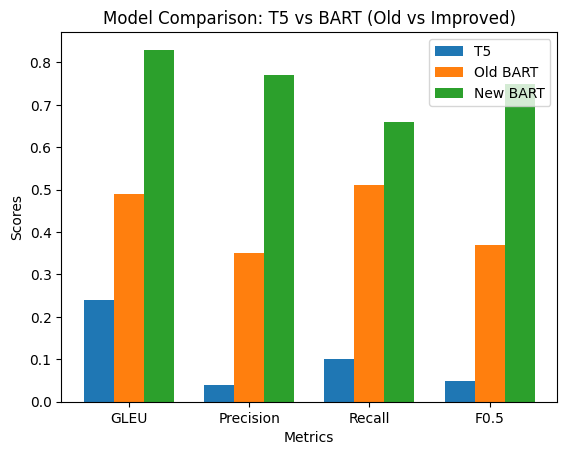

In [ ]:
labels = ["GLEU", "Precision", "Recall", "F0.5"]

t5_scores = [0.24, 0.04, 0.10, 0.05]
old_bart_scores = [0.49, 0.35, 0.51, 0.37]
new_bart_scores = [0.83, 0.77, 0.66, 0.75]

x = np.arange(len(labels))
width = 0.25

plt.figure()

plt.bar(x - width, t5_scores, width, label='T5')
plt.bar(x, old_bart_scores, width, label='Old BART')
plt.bar(x + width, new_bart_scores, width, label='New BART')

plt.xlabel("Metrics")
plt.ylabel("Scores")
plt.title("Model Comparison: T5 vs BART (Old vs Improved)")
plt.xticks(x, labels)
plt.legend()

plt.show()

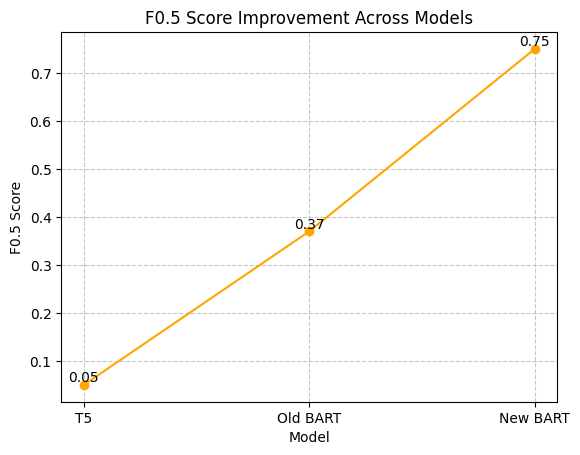

In [ ]:
import matplotlib.pyplot as plt

models = ["T5", "Old BART", "New BART"]
f05_scores = [0.05, 0.37, 0.75]

plt.figure()

plt.plot(models, f05_scores, marker='o',color='orange')


for i, v in enumerate(f05_scores):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.title("F0.5 Score Improvement Across Models")
plt.xlabel("Model")
plt.ylabel("F0.5 Score")

plt.grid(linestyle='--', alpha=0.7)

plt.show()

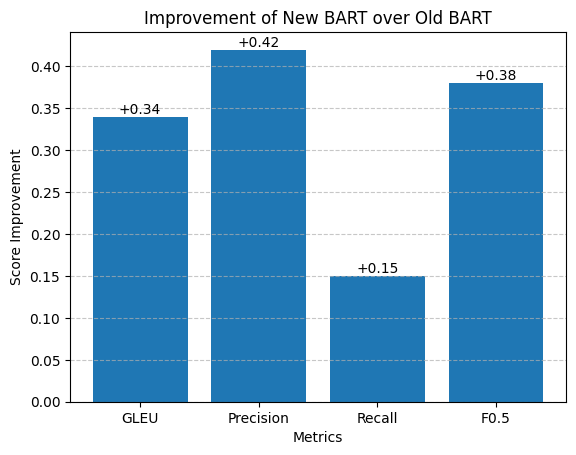

In [ ]:
plt.figure()

improvement = [n - o for n, o in zip(new_bart_scores, old_bart_scores)]

plt.bar(labels, improvement)

for i, v in enumerate(improvement):
    plt.text(i, v, f"+{v:.2f}", ha='center', va='bottom')

plt.title("Improvement of New BART over Old BART")
plt.xlabel("Metrics")
plt.ylabel("Score Improvement")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
bart_model.save_pretrained("/content/bart_improved_model")
bart_tokenizer.save_pretrained("/content/bart_improved_model")

('/content/bart_improved_model/tokenizer_config.json',
 '/content/bart_improved_model/tokenizer.json')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
bart_model.save_pretrained("/content/drive/MyDrive/bart_improved_model")
bart_tokenizer.save_pretrained("/content/drive/MyDrive/bart_improved_model")

('/content/drive/MyDrive/bart_improved_model/tokenizer_config.json',
 '/content/drive/MyDrive/bart_improved_model/tokenizer.json')